<a href="https://colab.research.google.com/github/gauravjha201/Brain_Tumor_Adversarial_Robustness/blob/main/Stage_D_PGD_attack.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Stage_D_PGD_attack**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
DATASET_PATH="/content/drive/MyDrive/Br35H"

val_dataset=tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32
)

val_dataset=val_dataset.map(lambda x,y:(x/255,y))

Found 3023 files belonging to 2 classes.
Using 604 files for validation.


In [6]:
model=tf.keras.models.load_model("/content/drive/MyDrive/baseline_model.h5")
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,083 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 2 (12.00 B)

In [7]:
clean_loss,clean_acc=model.evaluate(val_dataset)
print(f"Clean Accuracy: {clean_acc*100:.2f}%")
print(f"Clean Loss: {clean_loss:.4f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.9834 - loss: 0.0651
Clean Accuracy: 98.34%
Clean Loss: 0.0651


In [14]:
def pgd_attack(model,images,labels,epsilon,alpha,iterations):
  images=tf.cast(images,tf.float32)

  labels = tf.cast(labels, tf.float32)
  labels = tf.expand_dims(labels, axis=1)

  adv_images=images+tf.random.uniform(images.shape,-epsilon,epsilon)
  adv_images=tf.clip_by_value(adv_images,0,1)

  for i in range(iterations):
    with tf.GradientTape() as tape:
      tape.watch(adv_images)
      predictions=model(adv_images)
      loss=tf.keras.losses.binary_crossentropy(labels,predictions)

    gradient=tape.gradient(loss,adv_images)

    #Gradient step
    adv_images=adv_images+alpha*tf.sign(gradient)

    #prejection step
    adv_images=tf.clip_by_value(adv_images,images-epsilon,images+epsilon)

    #keep valid image range
    adv_images=tf.clip_by_value(adv_images,0,1)

  return adv_images






In [15]:
pgd_acc_list = []
pgd_loss_list = []

for images, labels in val_dataset:
    adv_images = pgd_attack(model, images, labels,
                            epsilon=0.03,
                            alpha=0.005,
                            iterations=20)

    loss, acc = model.evaluate(adv_images, labels, verbose=0)

    pgd_acc_list.append(acc)
    pgd_loss_list.append(loss)

pgd_acc = np.mean(pgd_acc_list)
pgd_loss = np.mean(pgd_loss_list)

print(f"PGD Accuracy: {pgd_acc*100:.2f}%")
print(f"PGD Loss: {pgd_loss:.4f}")

PGD Accuracy: 0.00%
PGD Loss: 62.4045


In [16]:
print("\n===== CLEAN vs PGD =====")
print(f"Clean Accuracy: {clean_acc*100:.2f}% | Loss: {clean_loss:.4f}")
print(f"PGD Accuracy: {pgd_acc*100:.2f}% | Loss: {pgd_loss:.4f}")


===== CLEAN vs PGD =====
Clean Accuracy: 98.34% | Loss: 0.0651
PGD Accuracy: 0.00% | Loss: 62.4045


In [17]:
y_true=[]
y_pred_clean=[]
y_pred_pgd=[]

for images,labels in val_dataset:
  adv_images=pgd_attack(model,images,labels,
                        epsilon=0.03,
                        alpha=0.005,
                        iterations=20)
  preds_clean=model.predict(images)
  preds_clean=(preds_clean>0.5).astype(int)

  preds_pgd=model.predict(adv_images)
  preds_pgd=(preds_pgd>0.5).astype(int)

  y_true.extend(labels.numpy())
  y_pred_clean.extend(preds_clean)
  y_pred_pgd.extend(preds_pgd)





1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━

In [18]:
print("=== CLEAN DATA ===")
print(confusion_matrix(y_true, y_pred_clean))

print("\n=== PGD DATA ===")
print(confusion_matrix(y_true, y_pred_pgd))

=== CLEAN DATA ===
[[294   4]
 [  6 300]]

=== PGD DATA ===
[[  0 298]
 [306   0]]


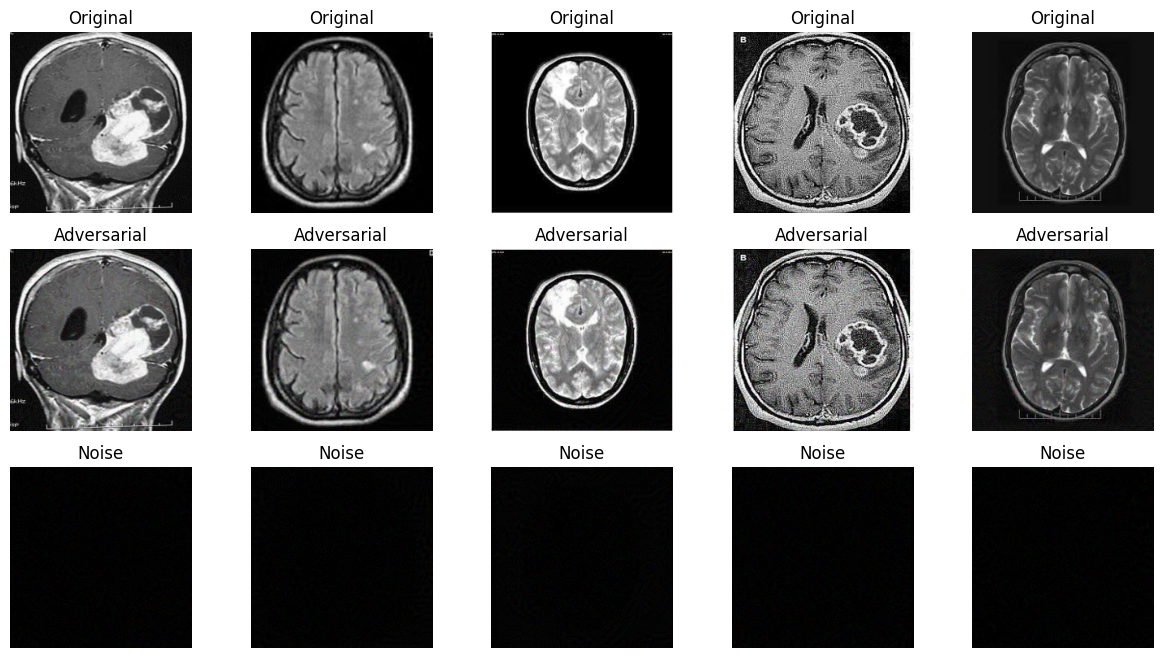

In [22]:
for images,labels in val_dataset.take(1):
  adv_images=pgd_attack(model,images,labels,
                        epsilon=0.03,
                        alpha=0.005,
                        iterations=20)

  plt.figure(figsize=(15,8))

  for i in range(5):

    plt.subplot(3,5,i+1)
    plt.imshow(images[i])
    plt.title("Original")
    plt.axis("off")

    plt.subplot(3,5,i+6)
    plt.imshow(adv_images[i])
    plt.title("Adversarial")
    plt.axis("off")

    plt.subplot(3,5,i+11)
    plt.imshow(adv_images[i]-images[i])
    plt.title("Noise")
    plt.axis("off")

  plt.show()


In [20]:
print("\n===== FINAL RESULT =====")
print(f"Clean Accuracy: {clean_acc*100:.2f}%")
print(f"PGD Accuracy: {pgd_acc*100:.2f}%")


===== FINAL RESULT =====
Clean Accuracy: 98.34%
PGD Accuracy: 0.00%


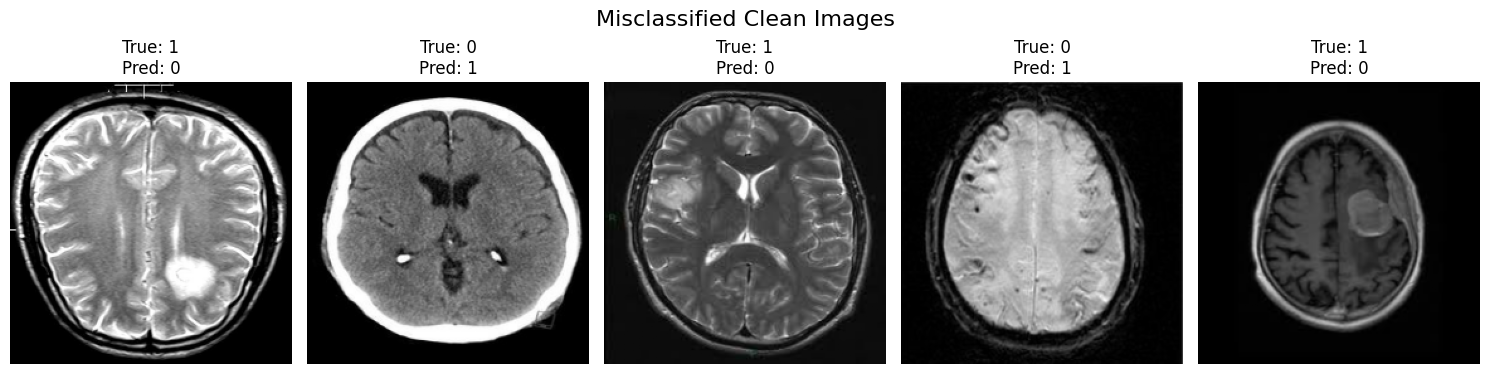

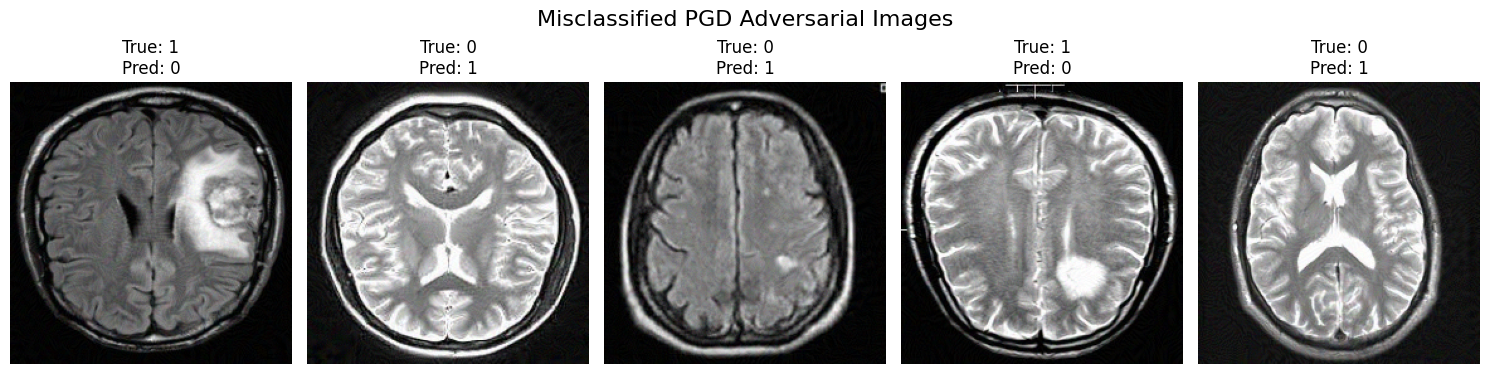

In [23]:
import matplotlib.pyplot as plt
import numpy as np

misclassified_clean_images = []
misclassified_clean_true_labels = []
misclassified_clean_pred_labels = []

misclassified_pgd_images = []
misclassified_pgd_true_labels = []
misclassified_pgd_pred_labels = []

max_display_images = 5 # Limit the number of images to display

# Iterate through the validation dataset to find misclassified examples
for images, labels in val_dataset:
    # Cast labels to float32 before passing to pgd_attack, which will handle its own expand_dims
    labels_float = tf.cast(labels, tf.float32)

    # Generate adversarial images
    adv_images = pgd_attack(model, images, labels_float,
                            epsilon=0.03,
                            alpha=0.005,
                            iterations=20)

    # Get predictions for clean images
    preds_clean_raw = model.predict(images, verbose=0)
    preds_clean = (preds_clean_raw > 0.5).astype(int)

    # Get predictions for adversarial images
    preds_pgd_raw = model.predict(adv_images, verbose=0)
    preds_pgd = (preds_pgd_raw > 0.5).astype(int)

    # Convert labels to numpy for easier comparison
    labels_np = labels.numpy()

    # Find and store misclassified clean images
    clean_mismatched_indices = np.where(preds_clean.flatten() != labels_np)[0]
    for idx in clean_mismatched_indices:
        if len(misclassified_clean_images) < max_display_images:
            misclassified_clean_images.append(images[idx].numpy())
            misclassified_clean_true_labels.append(labels_np[idx])
            misclassified_clean_pred_labels.append(preds_clean[idx][0])

    # Find and store misclassified PGD images
    pgd_mismatched_indices = np.where(preds_pgd.flatten() != labels_np)[0]
    for idx in pgd_mismatched_indices:
        if len(misclassified_pgd_images) < max_display_images:
            misclassified_pgd_images.append(adv_images[idx].numpy())
            misclassified_pgd_true_labels.append(labels_np[idx])
            misclassified_pgd_pred_labels.append(preds_pgd[idx][0])

    # Stop if we have enough examples of both types
    if len(misclassified_clean_images) >= max_display_images and \
       len(misclassified_pgd_images) >= max_display_images:
        break

# Display misclassified clean images
if misclassified_clean_images:
    plt.figure(figsize=(15, 4))
    plt.suptitle("Misclassified Clean Images", fontsize=16)
    for i in range(len(misclassified_clean_images)):
        plt.subplot(1, max_display_images, i + 1)
        plt.imshow(misclassified_clean_images[i])
        plt.title(f"True: {misclassified_clean_true_labels[i]}\nPred: {misclassified_clean_pred_labels[i]}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No clean images were misclassified in the sampled batches.")

# Display misclassified PGD adversarial images
if misclassified_pgd_images:
    plt.figure(figsize=(15, 4))
    plt.suptitle("Misclassified PGD Adversarial Images", fontsize=16)
    for i in range(len(misclassified_pgd_images)):
        plt.subplot(1, max_display_images, i + 1)
        plt.imshow(misclassified_pgd_images[i])
        plt.title(f"True: {misclassified_pgd_true_labels[i]}\nPred: {misclassified_pgd_pred_labels[i]}")
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    print("No PGD adversarial images were misclassified in the sampled batches.")

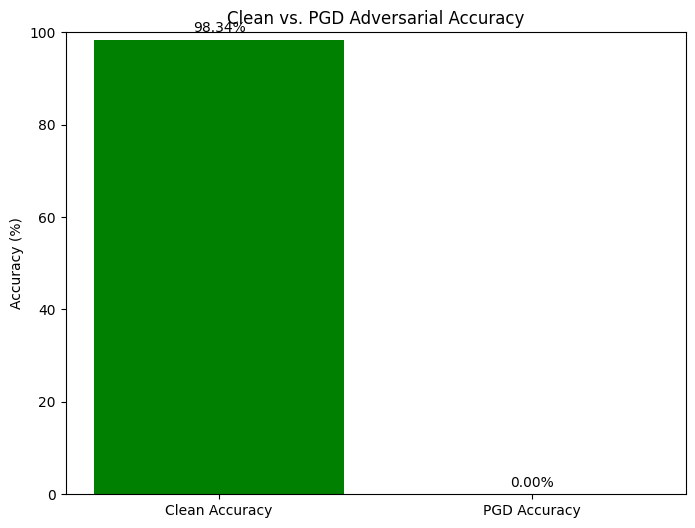

In [24]:
import matplotlib.pyplot as plt

labels = ['Clean Accuracy', 'PGD Accuracy']
accuracies = [clean_acc * 100, pgd_acc * 100]

plt.figure(figsize=(8, 6))
plt.bar(labels, accuracies, color=['green', 'red'])
plt.ylabel('Accuracy (%)')
plt.title('Clean vs. PGD Adversarial Accuracy')
plt.ylim(0, 100)

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 1, f'{acc:.2f}%', ha='center', va='bottom')

plt.show()